# AI_For_Bharat



## Startup cells

In [0]:
# Set environment variables for sagemaker_studio imports

import os
os.environ['DataZoneProjectId'] = '3i3y9t8dnzrcld'
os.environ['DataZoneDomainId'] = 'dzd-5z4n5rdmpqpbk1'
os.environ['DataZoneEnvironmentId'] = 'd23zln5ejcqidd'
os.environ['DataZoneDomainRegion'] = 'ap-south-1'

# create both a function and variable for metadata access
_resource_metadata = None

def _get_resource_metadata():
    global _resource_metadata
    if _resource_metadata is None:
        _resource_metadata = {
            "AdditionalMetadata": {
                "DataZoneProjectId": "3i3y9t8dnzrcld",
                "DataZoneDomainId": "dzd-5z4n5rdmpqpbk1",
                "DataZoneEnvironmentId": "d23zln5ejcqidd",
                "DataZoneDomainRegion": "ap-south-1",
            }
        }
    return _resource_metadata
metadata = _get_resource_metadata()

In [0]:
"""
Logging Configuration

Purpose:
--------
This sets up the logging framework for code executed in the user namespace.
"""

from typing import Optional


def _set_logging(log_dir: str, log_file: str, log_name: Optional[str] = None):
    import os
    import logging
    from logging.handlers import RotatingFileHandler

    level = logging.INFO
    max_bytes = 5 * 1024 * 1024
    backup_count = 5

    # fallback to /tmp dir on access, helpful for local dev setup
    try:
        os.makedirs(log_dir, exist_ok=True)
    except Exception:
        log_dir = "/tmp/kernels/"

    os.makedirs(log_dir, exist_ok=True)
    log_path = os.path.join(log_dir, log_file)

    logger = logging.getLogger() if not log_name else logging.getLogger(log_name)
    logger.handlers = []
    logger.setLevel(level)

    formatter = logging.Formatter("%(asctime)s - %(name)s - %(levelname)s - %(message)s")

    # Rotating file handler
    fh = RotatingFileHandler(filename=log_path, maxBytes=max_bytes, backupCount=backup_count, encoding="utf-8")
    fh.setFormatter(formatter)
    logger.addHandler(fh)

    logger.info(f"Logging initialized for {log_name}.")


_set_logging("/var/log/computeEnvironments/kernel/", "kernel.log")
_set_logging("/var/log/studio/data-notebook-kernel-server/", "metrics.log", "metrics")

In [0]:
import logging
from sagemaker_studio import ClientConfig, sqlutils, sparkutils, dataframeutils

logger = logging.getLogger(__name__)
logger.info("Initializing sparkutils")
spark = sparkutils.init()
logger.info("Finished initializing sparkutils")

In [0]:
def _reset_os_path():
    """
    Reset the process's working directory to handle mount timing issues.
    
    This function resolves a race condition where the Python process starts
    before the filesystem mount is complete, causing the process to reference
    old mount paths and inodes. By explicitly changing to the mounted directory
    (/home/sagemaker-user), we ensure the process uses the correct, up-to-date
    mount point.
    
    The function logs stat information (device ID and inode) before and after
    the directory change to verify that the working directory is properly
    updated to reference the new mount.
    
    Note:
        This is executed at module import time to ensure the fix is applied
        as early as possible in the kernel initialization process.
    """
    try:
        import os
        import logging

        logger = logging.getLogger(__name__)
        logger.info("---------Before------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)

        os.chdir("/home/sagemaker-user")

        logger.info("---------After------")
        logger.info("CWD: %s", os.getcwd())
        logger.info("stat('.'): %s %s", os.stat('.').st_dev, os.stat('.').st_ino)
        logger.info("stat('/home/sagemaker-user'): %s %s", os.stat('/home/sagemaker-user').st_dev, os.stat('/home/sagemaker-user').st_ino)
    except Exception as e:
        logger.exception(f"Failed to reset working directory: {e}")

_reset_os_path()

## Notebook

In [0]:
import boto3
import pandas as pd
from io import StringIO

In [0]:
bucket = 'ai-for-bharat-s3'
key = 'household_power_consumption.txt'

In [0]:
s3 = boto3.client('s3')
obj = s3.get_object(Bucket=bucket, Key=key)
power = pd.read_csv(StringIO(obj['Body'].read().decode('utf-8')), sep=';')

/tmp/ipykernel_57/3470431939.py:3: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  power = pd.read_csv(StringIO(obj['Body'].read().decode('utf-8')), sep=';')


In [0]:
power.shape

(2075259, 9)

In [0]:
#Importing Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

In [0]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [0]:
power.describe()

,Sub_metering_3
count,2.049280e+06
mean,6.458447e+00
std,8.437154e+00
min,0.000000e+00
25%,0.000000e+00
50%,1.000000e+00
75%,1.700000e+01
max,3.100000e+01


In [0]:
power.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

Here, we can see that only Sub_Metering_3 column has Null values. 

In [0]:
#Calculating the percentage of Null values for Sub_metering_3 column

(int(power['Sub_metering_3'].isnull().sum())/power.shape[0])*100

1.2518437457686005

<Axes: title={'center': 'Sub_metering_3'}, ylabel='Sub_metering_3'>

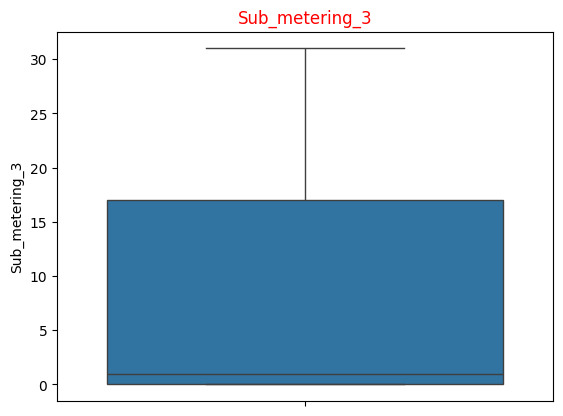

In [0]:
#Boxplot of Sub_metering_3 column
plt.title('Sub_metering_3', fontdict={'color' : 'Red'})

sns.boxplot(power['Sub_metering_3'])

In [0]:
power['Sub_metering_3'].describe()

count    2.049280e+06
mean     6.458447e+00
std      8.437154e+00
min      0.000000e+00
25%      0.000000e+00
50%      1.000000e+00
75%      1.700000e+01
max      3.100000e+01
Name: Sub_metering_3, dtype: float64

As per the statistics, this column Sub_Metering_3 is highly skewed. Mean value is 6.45 which is distorted to high values whereas Median i.e. 50th percentile is more robust to outliers. So let's replace the missing values with the Median value.

In [0]:
power['Sub_metering_3'].fillna(power['Sub_metering_3'].median(), inplace=True)

/tmp/ipykernel_57/3950573394.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  power['Sub_metering_3'].fillna(power['Sub_metering_3'].median(), inplace=True)


In [0]:
power.isnull().sum()

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

Now, we can see that there aren't any Null values for any column

In [0]:
power.columns

Index(['Date', 'Time', 'Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3'],
      dtype='object')

Let's create a list of numeric columns which will help us to capture anomalies. 

In [0]:
numeric_cols = ['Global_active_power', 'Global_reactive_power',
       'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2',
       'Sub_metering_3']

for n in numeric_cols:
       print(power[n].dtype)

object
object
object
object
object
object
float64


Here, we can see that except the Sub_metering_3 variable, rest all are of generic object datatype in Pandas. Firstly, let's remove the 'dirty' numeric strings. These consists of things like empty strings, trailing spaces, or non-standard characters (like commas or currency symbols).

In [0]:
for n in numeric_cols:
    power[n] = (power[n].astype(str).str.strip().replace(['', 'None', 'nan', '-'], pd.NA))

In [0]:
#Converting the variables values to numeric values

for n in numeric_cols:
    power[n] = pd.to_numeric(power[n], errors='coerce')

In [0]:
for n in numeric_cols:
    print(power[n].dtype)

float64
float64
float64
float64
float64
float64
float64


Now, we can see that all variables to be used for anomaly detection are of type float. 

In [0]:
power.shape

(2075259, 9)

In [0]:
power.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


<Axes: title={'center': 'Voltage'}, ylabel='Voltage'>

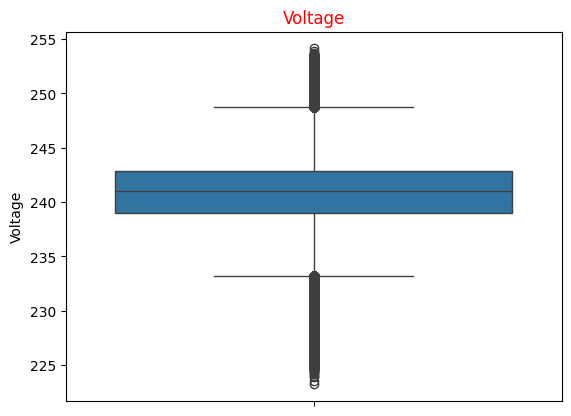

In [0]:
#Volatge variable distribution

plt.title('Voltage', fontdict={'color' : 'Red'})
sns.boxplot(power['Voltage'])

As seen from the above boxplot image of Voltage, the average range of volage value is approximately between 238V-242V.

# Isolation Forest Machine Learning Algorithm

In [0]:
#Importing isolation forest algorithm from sklearn library

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [0]:
scaler = StandardScaler()
X = scaler.fit_transform(power[numeric_cols])

In [0]:
iso = IsolationForest(contamination=0.01, random_state=42)
power['anamoly'] = iso.fit_predict(X)

In [0]:
print(f"Anomalies: {(power['anamoly']==-1).sum()} / {len(power)}")

Anomalies: 20753 / 2075259


Now, let's plot anomalies captured for voltage

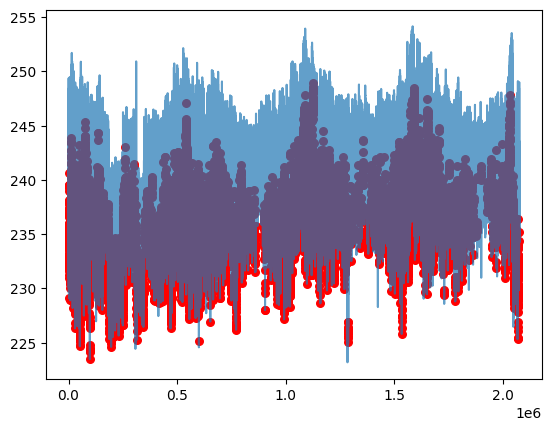

In [0]:
plt.plot(power.index, power['Voltage'], alpha=0.7)

plt.scatter(power[power['anamoly']==-1].index, power[power['anamoly']==-1]['Voltage'], c='red', s=30)

plt.show()

From the above image, we can see the red points indicate the voltage drops.

/sagemaker_packages/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


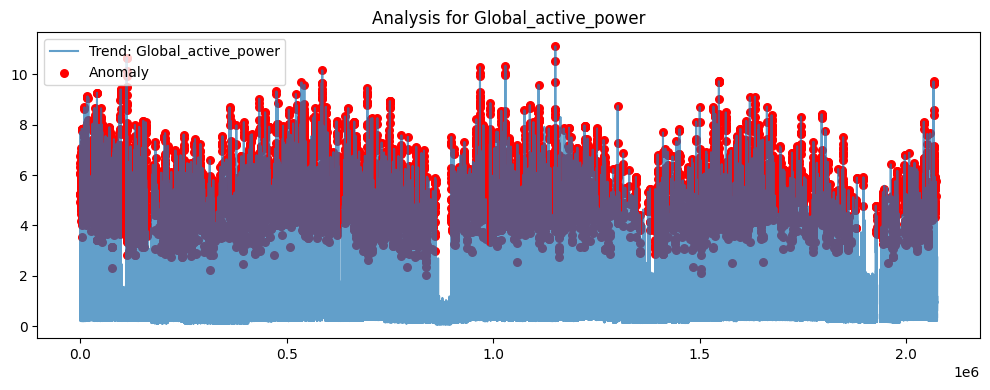

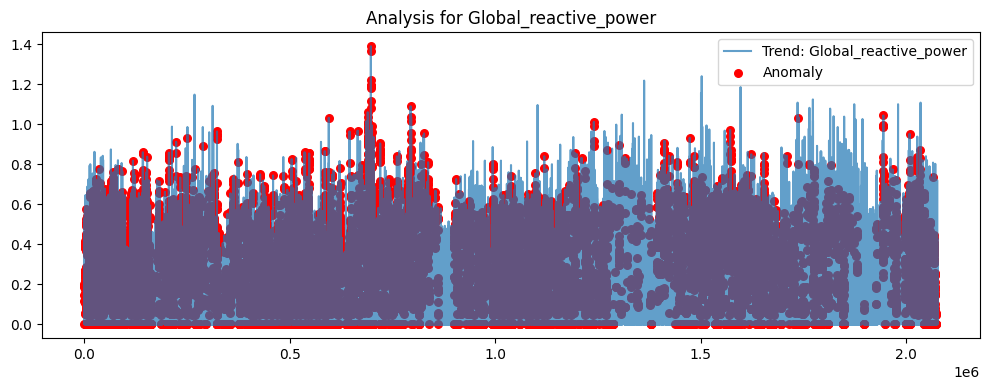

/tmp/ipykernel_57/1504005465.py:15: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


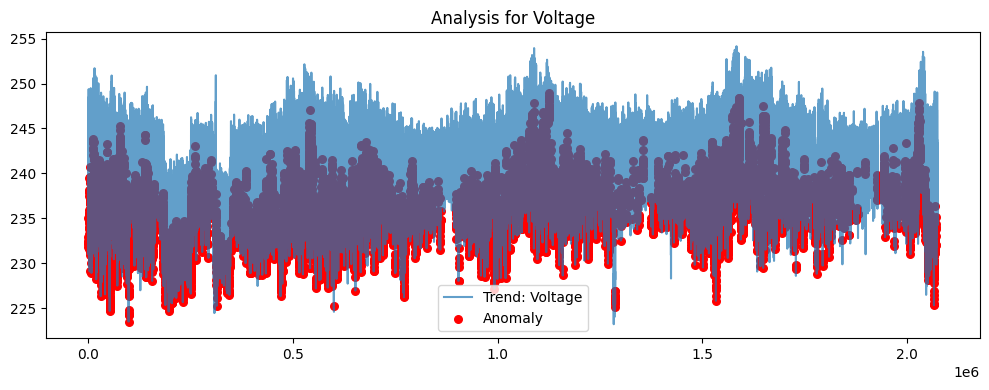

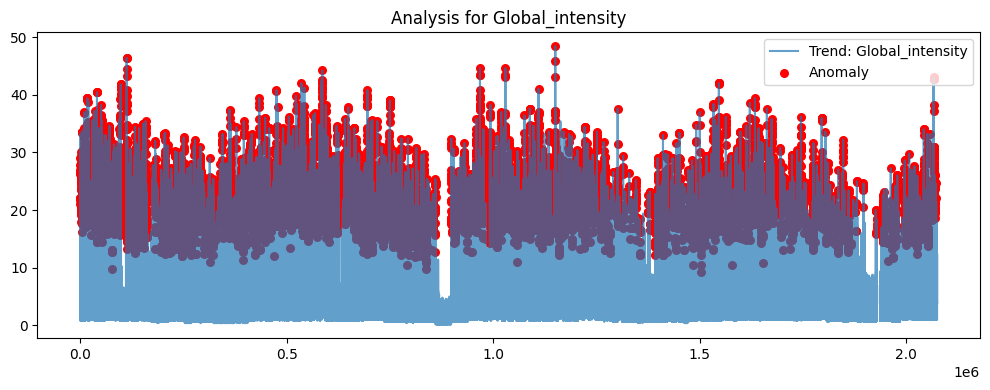

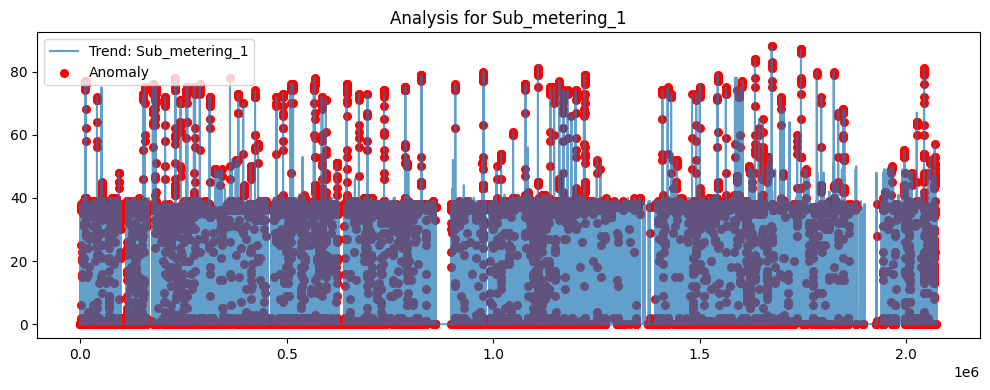

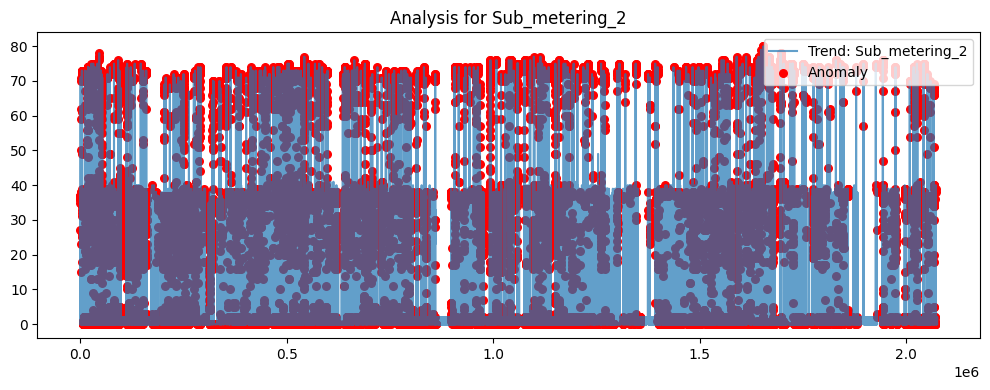

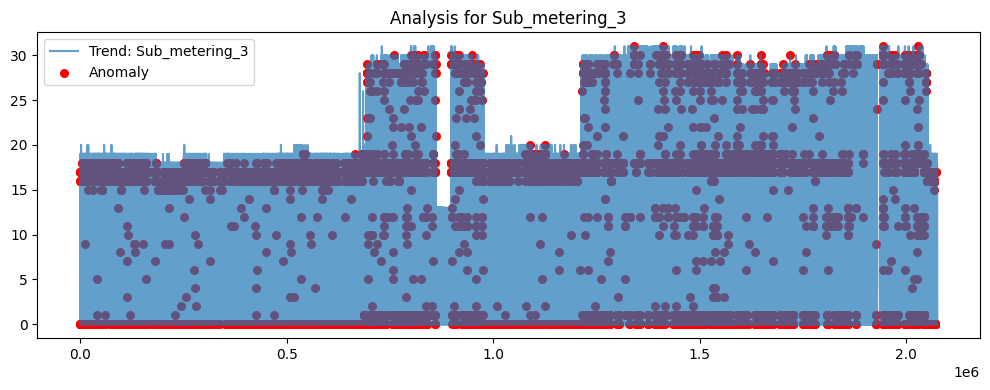

In [0]:
#Plotting the anomalies for other variables as well

for n in numeric_cols:
    plt.figure(figsize=(10, 4)) # Forces a brand new window/plot area
    
    # Line plot of the data
    plt.plot(power.index, power[n], alpha=0.7, label=f'Trend: {n}')
    
    # Scatter plot of anomalies
    anomalies = power[power['anamoly'] == -1]
    plt.scatter(anomalies.index, anomalies[n], c='red', s=30, label='Anomaly')
    
    plt.title(f'Analysis for {n}')
    plt.legend()
    plt.tight_layout()
    plt.show()

# **Anomaly Scenario** : 

1.	Voltage spike without Active power spike  Grid issue
2.	Active power spike without voltage change  Appliance fault
3.	Sub-metering-1 spike + Global intensity spike  Kitchen problem
4.	Reactive power surge  Power factor issue
5.	All 7 aligned spikes  Serious Grid events

As mentioned in the above scenarios, the ML model with Isolation forest algorithms monitor these anomalies and expected issues relating to the spikes observed. 

In [0]:
power.shape

(2075259, 10)

*Now, finally let's save the CSV file back to our S3 bucket which contains our anomalies detected column. *

In [0]:
power.to_csv('s3://ai-for-bharat-s3/anomalies_detected.csv', index=False)

## Shutdown cells

In [0]:
"""
Stop spark session and associated Athena Spark session
"""

from IPython import get_ipython as _get_ipython
_get_ipython().user_ns["spark"].stop()